In [ ]:
!pip install faker
!pip install sqlalchemy
!pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 72.4 MB/s eta 0:00:00


In [ ]:
!pip install faker pandas numpy

In [ ]:

# ==========================
# FinHealth Monitor
# Customer Data Generation
# ==========================

!pip install faker pandas numpy -q

from faker import Faker
import pandas as pd
import numpy as np
from datetime import datetime

# Reproducibility
np.random.seed(42)

# Initialize Faker
fake = Faker("en_GB")

# Number of customers
NUM_CUSTOMERS = 5000

# Lists used for realistic business logic
segments = ["Standard", "Premium", "Business"]
segment_weights = [0.70, 0.25, 0.05]

channels = [
    "Organic",
    "Google Ads",
    "LinkedIn",
    "Referral",
    "Facebook Ads"
]

channel_weights = [0.30, 0.25, 0.10, 0.20, 0.15]

genders = ["Male", "Female", "Non-Binary"]
gender_weights = [0.48, 0.48, 0.04]

customers = []

for customer_id in range(1, NUM_CUSTOMERS + 1):

    # Customer segment
    segment = np.random.choice(
        segments,
        p=segment_weights
    )

    # Monthly income based on segment
    if segment == "Standard":
        monthly_income = np.random.randint(1800, 5000)

    elif segment == "Premium":
        monthly_income = np.random.randint(5000, 12000)

    else:
        monthly_income = np.random.randint(12000, 35000)

    # Credit score
    credit_score = int(
        np.clip(
            np.random.normal(700, 80),
            300,
            850
        )
    )

    # Risk level
    if credit_score >= 750:
        risk_level = "Low"

    elif credit_score >= 650:
        risk_level = "Medium"

    else:
        risk_level = "High"

    # Active customers
    is_active = np.random.choice(
        [True, False],
        p=[0.88, 0.12]
    )

    # Churn probability based on risk
    if risk_level == "High":
        churn_flag = np.random.choice(
            [True, False],
            p=[0.30, 0.70]
        )

    elif risk_level == "Medium":
        churn_flag = np.random.choice(
            [True, False],
            p=[0.15, 0.85]
        )

    else:
        churn_flag = np.random.choice(
            [True, False],
            p=[0.05, 0.95]
        )

    customer = {

        "customer_id": customer_id,

        "full_name": fake.name(),

        "email": fake.email(),

        "birth_date": fake.date_of_birth(
            minimum_age=18,
            maximum_age=80
        ),

        "gender": np.random.choice(
            genders,
            p=gender_weights
        ),

        "city": fake.city(),

        "state": fake.country(),

        "signup_date": fake.date_between(
            start_date="-3y",
            end_date="today"
        ),

        "customer_segment": segment,

        "acquisition_channel": np.random.choice(
            channels,
            p=channel_weights
        ),

        "monthly_income": monthly_income,

        "credit_score": credit_score,

        "risk_level": risk_level,

        "is_active": is_active,

        "churn_flag": churn_flag
    }

    customers.append(customer)

# Create DataFrame
customers_df = pd.DataFrame(customers)

# Preview
print("Dataset Shape:")
print(customers_df.shape)

print("\nFirst 5 Rows:")
display(customers_df.head())

print("\nData Types:")
print(customers_df.info())

print("\nMissing Values:")
print(customers_df.isnull().sum())

# Save CSV
customers_df.to_csv(
    "customers.csv",
    index=False
)

print("\ncustomers.csv saved successfully.")

Dataset Shape:
(5000, 15)

First 5 Rows:


,customer_id,full_name,email,birth_date,gender,city,state,signup_date,customer_segment,acquisition_channel,monthly_income,credit_score,risk_level,is_active,churn_flag
0,1,Kerry Hall-Warren,kevin79@example.net,1975-07-25,Male,Lake Rachel,Christmas Island,2026-05-25,Standard,Google Ads,2660,743,Medium,True,False
1,2,Miss Helen Burns,jarnold@example.org,1951-03-16,Non-Binary,Butchertown,Armenia,2023-08-31,Standard,Referral,4719,650,Medium,True,True
2,3,Susan Anderson,adamsmax@example.net,1945-08-16,Non-Binary,East Garry,Heard Island and McDonald Islands,2025-03-06,Standard,Organic,3015,701,Medium,True,True
3,4,Jennifer Davey,neil90@example.org,1994-01-21,Female,Brucefort,Iran,2024-10-23,Standard,Organic,4805,665,Medium,True,False
4,5,Edward Morris,chandlerkevin@example.com,1955-09-24,Male,Elizabethchester,Uganda,2023-09-11,Standard,Organic,3868,676,Medium,False,False



Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          5000 non-null   int64 
 1   full_name            5000 non-null   object
 2   email                5000 non-null   object
 3   birth_date           5000 non-null   object
 4   gender               5000 non-null   object
 5   city                 5000 non-null   object
 6   state                5000 non-null   object
 7   signup_date          5000 non-null   object
 8   customer_segment     5000 non-null   object
 9   acquisition_channel  5000 non-null   object
 10  monthly_income       5000 non-null   int64 
 11  credit_score         5000 non-null   int64 
 12  risk_level           5000 non-null   object
 13  is_active            5000 non-null   bool  
 14  churn_flag           5000 non-null   bool  
dtypes: bool(2), int64(3), object(10)
memory us

In [ ]:
# ==========================
# FinHealth Monitor
# Transaction Data Generation
# ==========================

import pandas as pd
import numpy as np
from faker import Faker

fake = Faker("en_GB")

# Number of transactions
NUM_TRANSACTIONS = 100000

# Transaction types
transaction_types = [
    "Card Payment",
    "Bank Transfer",
    "Direct Debit",
    "ATM Withdrawal",
    "Online Purchase"
]

transaction_type_weights = [
    0.35,
    0.20,
    0.10,
    0.10,
    0.25
]

# Merchant categories
merchant_categories = [
    "Groceries",
    "Travel",
    "Restaurants",
    "Utilities",
    "Shopping",
    "Healthcare",
    "Entertainment",
    "Subscriptions"
]

# Device types
device_types = [
    "Mobile",
    "Desktop",
    "Tablet"
]

device_weights = [
    0.75,
    0.20,
    0.05
]

# Transaction status
statuses = [
    "Completed",
    "Pending",
    "Failed"
]

status_weights = [
    0.95,
    0.03,
    0.02
]

transactions = []

for transaction_id in range(1, NUM_TRANSACTIONS + 1):

    # Random customer
    customer = customers_df.sample(1).iloc[0]

    customer_id = customer["customer_id"]
    segment = customer["customer_segment"]

    # Transaction amount depends on customer segment
    if segment == "Standard":
        amount = round(np.random.uniform(10, 300), 2)

    elif segment == "Premium":
        amount = round(np.random.uniform(100, 1500), 2)

    else:
        amount = round(np.random.uniform(500, 10000), 2)

    # Inject anomalies (~1%)
    anomaly_flag = np.random.choice(
        [True, False],
        p=[0.01, 0.99]
    )

    if anomaly_flag:
        amount *= np.random.randint(20, 80)

    # Fraud simulation (~1.5%)
    is_fraud = np.random.choice(
        [True, False],
        p=[0.015, 0.985]
    )

    # Fintech fee (0.5%)
    transaction_fee = round(amount * 0.005, 2)

    transaction = {

        "transaction_id": transaction_id,

        "customer_id": customer_id,

        "transaction_date": fake.date_time_between(
            start_date="-2y",
            end_date="now"
        ),

        "transaction_type": np.random.choice(
            transaction_types,
            p=transaction_type_weights
        ),

        "amount": round(amount, 2),

        "transaction_fee": transaction_fee,

        "status": np.random.choice(
            statuses,
            p=status_weights
        ),

        "merchant_category": np.random.choice(
            merchant_categories
        ),

        "device_type": np.random.choice(
            device_types,
            p=device_weights
        ),

        "country": fake.country(),

        "is_fraud": is_fraud,

        "anomaly_flag": anomaly_flag
    }

    transactions.append(transaction)

# Create DataFrame
transactions_df = pd.DataFrame(transactions)

print("Dataset Shape:")
print(transactions_df.shape)

print("\nFirst 5 Rows:")
display(transactions_df.head())

print("\nData Types:")
print(transactions_df.info())

print("\nMissing Values:")
print(transactions_df.isnull().sum())

# Save CSV
transactions_df.to_csv(
    "transactions.csv",
    index=False
)

print("\ntransactions.csv saved successfully.")

Dataset Shape:
(100000, 12)

First 5 Rows:


,transaction_id,customer_id,transaction_date,transaction_type,amount,transaction_fee,status,merchant_category,device_type,country,is_fraud,anomaly_flag
0,1,3768,2026-06-06 04:22:59.671052,Bank Transfer,8571.69,42.86,Completed,Groceries,Mobile,British Virgin Islands,False,False
1,2,3545,2024-11-16 08:59:02.033719,Card Payment,1475.09,7.38,Completed,Healthcare,Mobile,Norfolk Island,False,False
2,3,636,2024-07-30 08:37:49.122563,Card Payment,1116.16,5.58,Completed,Restaurants,Mobile,Morocco,False,False
3,4,432,2024-09-11 19:27:10.953933,ATM Withdrawal,85.97,0.43,Completed,Healthcare,Desktop,American Samoa,False,False
4,5,1113,2026-07-11 02:04:24.894753,Card Payment,204.59,1.02,Completed,Subscriptions,Desktop,Iraq,False,False



Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   transaction_id     100000 non-null  int64         
 1   customer_id        100000 non-null  int64         
 2   transaction_date   100000 non-null  datetime64[ns]
 3   transaction_type   100000 non-null  object        
 4   amount             100000 non-null  float64       
 5   transaction_fee    100000 non-null  float64       
 6   status             100000 non-null  object        
 7   merchant_category  100000 non-null  object        
 8   device_type        100000 non-null  object        
 9   country            100000 non-null  object        
 10  is_fraud           100000 non-null  bool          
 11  anomaly_flag       100000 non-null  bool          
dtypes: bool(2), datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 7.8+ MB
Non

In [ ]:
# Revenue generated by fees
transactions_df["transaction_fee"].sum()

np.float64(421131.67999999993)

In [ ]:
# Fraud rate
transactions_df["is_fraud"].mean() * 100

np.float64(1.481)

In [ ]:
# Anomaly rate
transactions_df["anomaly_flag"].mean() * 100

np.float64(1.011)

In [ ]:
# Transactions by segment
transactions_df.merge(
    customers_df[["customer_id", "customer_segment"]],
    on="customer_id"
)["customer_segment"].value_counts()

,count
customer_segment,
Standard,71117
Premium,23817
Business,5066


In [ ]:
# Revenue by segment
transactions_df.merge(
    customers_df[["customer_id", "customer_segment"]],
    on="customer_id"
).groupby("customer_segment")["amount"].sum()

,amount
customer_segment,
Business,39791632.78
Premium,27934512.02
Standard,16500046.04


In [ ]:
!pip install scikit-learn

In [ ]:
HIGH_AMOUNT_THRESHOLD = 20000

transactions_df["rule_alert"] = (
    transactions_df["amount"] > HIGH_AMOUNT_THRESHOLD
)

In [ ]:
transactions_df["rule_alert"].value_counts()

,count
rule_alert,
False,99744
True,256


In [ ]:
from scipy.stats import zscore

In [ ]:
transactions_df["z_score"] = zscore(
    transactions_df["amount"]
)

In [ ]:
transactions_df["zscore_alert"] = (
    abs(transactions_df["z_score"]) > 3
)

In [ ]:
transactions_df["zscore_alert"].value_counts()

,count
zscore_alert,
False,99784
True,216


In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
X = transactions_df[["amount"]]

In [ ]:
iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

In [ ]:
iso_model.fit(X)

IsolationForest(contamination=0.01, random_state=42)

In [ ]:
import pandas as pd

transactions = pd.DataFrame(transactions)

In [ ]:
type(transactions)

pandas.core.frame.DataFrame

In [ ]:
transactions.head()

,transaction_id,customer_id,transaction_date,transaction_type,amount,transaction_fee,status,merchant_category,device_type,country,is_fraud,anomaly_flag
0,1,3768,2026-06-06 04:22:59.671052,Bank Transfer,8571.69,42.86,Completed,Groceries,Mobile,British Virgin Islands,False,False
1,2,3545,2024-11-16 08:59:02.033719,Card Payment,1475.09,7.38,Completed,Healthcare,Mobile,Norfolk Island,False,False
2,3,636,2024-07-30 08:37:49.122563,Card Payment,1116.16,5.58,Completed,Restaurants,Mobile,Morocco,False,False
3,4,432,2024-09-11 19:27:10.953933,ATM Withdrawal,85.97,0.43,Completed,Healthcare,Desktop,American Samoa,False,False
4,5,1113,2026-07-11 02:04:24.894753,Card Payment,204.59,1.02,Completed,Subscriptions,Desktop,Iraq,False,False


In [ ]:
X = transactions[["amount"]]

In [ ]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_model.fit(X)

transactions["if_prediction"] = iso_model.predict(X)

transactions["if_alert"] = (
    transactions["if_prediction"] == -1
)

In [ ]:
transactions["rule_alert"] = (
    transactions["amount"] >
    transactions["amount"].quantile(0.99)
)

In [ ]:
from scipy.stats import zscore

transactions["z_score"] = zscore(transactions["amount"])

transactions["zscore_alert"] = (
    transactions["z_score"].abs() > 3
)

In [ ]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

X = transactions[["amount"]]

iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_model.fit(X)

transactions["if_prediction"] = iso_model.predict(X)
transactions["if_alert"] = transactions["if_prediction"] == -1

transactions["rule_alert"] = (
    transactions["amount"] >
    transactions["amount"].quantile(0.99)
)

transactions["z_score"] = zscore(transactions["amount"])
transactions["zscore_alert"] = transactions["z_score"].abs() > 3

In [ ]:
transactions.columns


Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_type',
       'amount', 'transaction_fee', 'status', 'merchant_category',
       'device_type', 'country', 'is_fraud', 'anomaly_flag', 'if_prediction',
       'if_alert', 'rule_alert', 'z_score', 'zscore_alert'],
      dtype='object')

In [ ]:
transactions.to_csv("transactions.csv", index=False)

print("transactions.csv salvo com sucesso!")

transactions.csv salvo com sucesso!


In [ ]:
# ===========================
# ISOLATION FOREST PREDICTIONS
# ===========================

transactions["if_prediction"] = iso_model.predict(X)

transactions["if_alert"] = (
    transactions["if_prediction"] == -1
)

In [ ]:
type(transactions)

pandas.core.frame.DataFrame

In [ ]:
transactions[:3]

,transaction_id,customer_id,transaction_date,transaction_type,amount,transaction_fee,status,merchant_category,device_type,country,is_fraud,anomaly_flag,if_prediction,if_alert,rule_alert,z_score,zscore_alert
0,1,3768,2026-06-06 04:22:59.671052,Bank Transfer,8571.69,42.86,Completed,Groceries,Mobile,British Virgin Islands,False,False,1,False,False,1.046144,False
1,2,3545,2024-11-16 08:59:02.033719,Card Payment,1475.09,7.38,Completed,Healthcare,Mobile,Norfolk Island,False,False,1,False,False,0.085650,False
2,3,636,2024-07-30 08:37:49.122563,Card Payment,1116.16,5.58,Completed,Restaurants,Mobile,Morocco,False,False,1,False,False,0.037071,False


In [ ]:
# ===========================
# RULE-BASED ALERT
# ===========================

transactions["rule_alert"] = (
    transactions["amount"] >
    transactions["amount"].quantile(0.99)
)

In [ ]:
from scipy.stats import zscore

transactions["z_score"] = zscore(transactions["amount"])

transactions["zscore_alert"] = (
    transactions["z_score"].abs() > 3
)

In [ ]:
transactions[
    [
        "amount",
        "rule_alert",
        "z_score",
        "zscore_alert",
        "if_prediction",
        "if_alert"
    ]
].head()

,amount,rule_alert,z_score,zscore_alert,if_prediction,if_alert
0,8571.69,False,1.046144,False,1,False
1,1475.09,False,0.085650,False,1,False
2,1116.16,False,0.037071,False,1,False
3,85.97,False,-0.102361,False,1,False
4,204.59,False,-0.086306,False,1,False


In [ ]:
transactions_df["if_prediction"] = (
    iso_model.predict(X)
)

In [ ]:
transactions_df["if_alert"] = (
    transactions_df["if_prediction"] == -1
)

In [ ]:
transactions_df["if_alert"].value_counts()

,count
if_alert,
False,99003
True,997


In [ ]:
alerts_df = transactions_df[
    (
        transactions_df["rule_alert"]
    )
    |
    (
        transactions_df["zscore_alert"]
    )
    |
    (
        transactions_df["if_alert"]
    )
].copy()

In [ ]:
print(
    f"Alerts generated: {len(alerts_df)}"
)

Alerts generated: 997


In [ ]:
alerts_df.head()

,transaction_id,customer_id,transaction_date,transaction_type,amount,transaction_fee,status,merchant_category,device_type,country,is_fraud,anomaly_flag,rule_alert,z_score,zscore_alert,if_prediction,if_alert
37,38,3980,2024-08-10 21:38:10.210475,Online Purchase,9126.49,45.63,Completed,Subscriptions,Mobile,Lao People's Democratic Republic,False,False,False,1.121234,False,-1,True
132,133,1393,2025-08-24 13:28:01.094752,Bank Transfer,9250.00,46.25,Completed,Subscriptions,Desktop,Poland,False,True,False,1.137950,False,-1,True
190,191,4616,2025-03-31 05:54:48.992304,Online Purchase,169643.25,848.22,Completed,Travel,Mobile,France,False,True,True,22.846465,True,-1,True
373,374,1463,2024-09-29 11:38:17.545252,Card Payment,67111.80,335.56,Completed,Groceries,Mobile,United States Minor Outlying Islands,False,True,True,8.969288,True,-1,True
458,459,3980,2025-08-22 18:24:10.251009,Online Purchase,9724.42,48.62,Failed,Restaurants,Mobile,Brazil,False,False,False,1.202161,False,-1,True


In [ ]:
alerts_df.to_csv(
    "transaction_alerts.csv",
    index=False
)

In [ ]:
anomaly_summary = {

    "total_transactions":
        len(transactions_df),

    "rule_alerts":
        transactions_df["rule_alert"].sum(),

    "zscore_alerts":
        transactions_df["zscore_alert"].sum(),

    "if_alerts":
        transactions_df["if_alert"].sum(),

    "fraud_transactions":
        transactions_df["is_fraud"].sum()
}

anomaly_summary

{'total_transactions': 100000,
 'rule_alerts': np.int64(256),
 'zscore_alerts': np.int64(216),
 'if_alerts': np.int64(997),
 'fraud_transactions': np.int64(1481)}

In [ ]:
alerts_df.shape

(997, 17)

In [ ]:
transactions_df["zscore_alert"].value_counts()

,count
zscore_alert,
False,99784
True,216


In [ ]:
!pip install prophet

In [ ]:
revenue_df = (
    transactions_df
    .groupby(
        transactions_df["transaction_date"].dt.date
    )["transaction_fee"]
    .sum()
    .reset_index()
)

In [ ]:
revenue_df.columns = ["ds", "y"]

revenue_df.head()

,ds,y
0,2024-07-12,241.82
1,2024-07-13,856.03
2,2024-07-14,829.76
3,2024-07-15,2058.42
4,2024-07-16,391.00


In [ ]:
from prophet import Prophet

revenue_model = Prophet()

revenue_model.fit(revenue_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = revenue_model.make_future_dataframe(
    periods=90
)

In [ ]:
revenue_forecast = revenue_model.predict(
    future
)

In [ ]:
revenue_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
816,2026-10-06,586.163706,37.437996,1127.526517
817,2026-10-07,665.799663,104.208997,1228.066804
818,2026-10-08,696.293439,182.895088,1268.542672
819,2026-10-09,598.968285,53.666436,1159.369488
820,2026-10-10,676.472269,129.425595,1224.983373


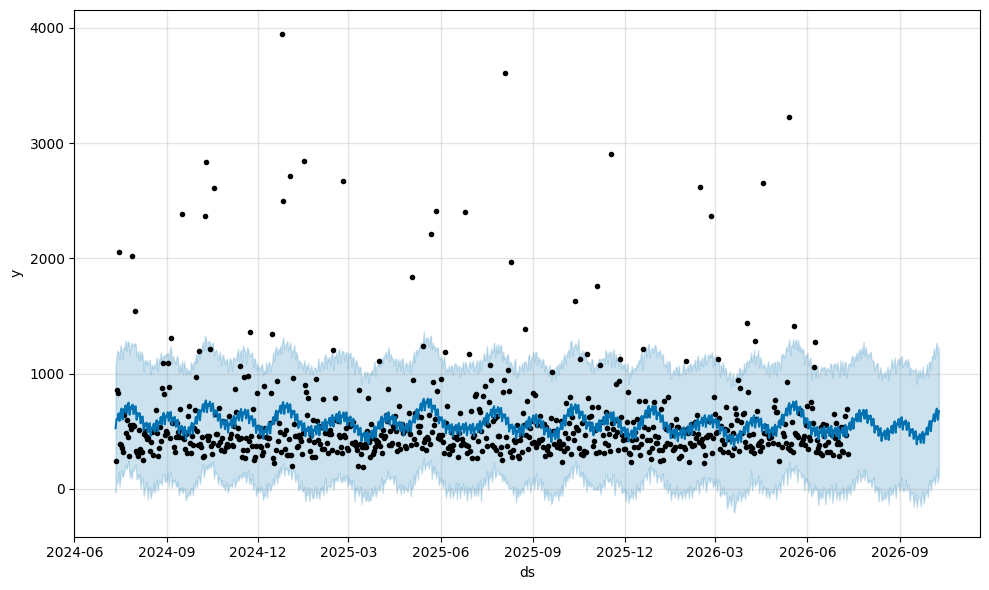

In [ ]:
fig1 = revenue_model.plot(
    revenue_forecast
)

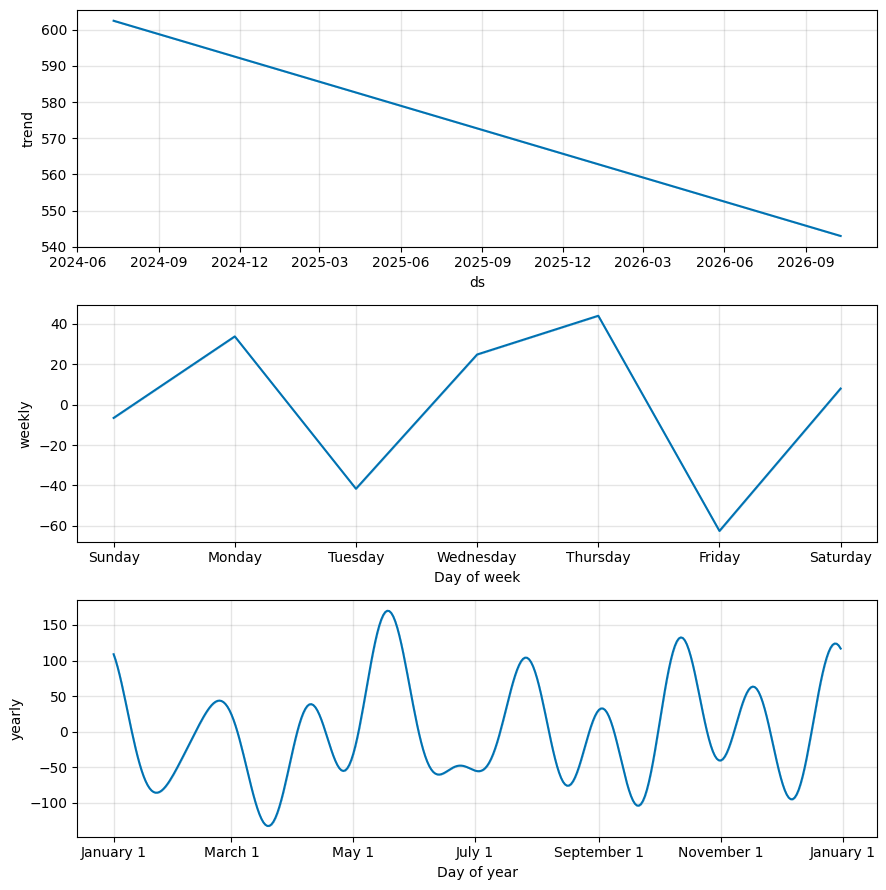

In [ ]:
fig2 = revenue_model.plot_components(
    revenue_forecast
)

In [ ]:
forecast_output = revenue_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

forecast_output.to_csv(
    "revenue_forecast.csv",
    index=False
)

In [ ]:
forecast_30d = forecast_output.tail(90).head(30)

forecast_30d["yhat"].sum()

np.float64(17899.638185227857)

In [ ]:
forecast_60d = forecast_output.tail(90).head(60)

forecast_60d["yhat"].sum()

np.float64(33755.68734710816)

In [ ]:
forecast_output.tail(90)["yhat"].sum()

np.float64(49327.87889187459)

In [ ]:
forecast_summary = {

    "forecast_30_days":
        round(
            forecast_30d["yhat"].sum(),
            2
        ),

    "forecast_60_days":
        round(
            forecast_60d["yhat"].sum(),
            2
        ),

    "forecast_90_days":
        round(
            forecast_output.tail(90)["yhat"].sum(),
            2
        )
}

forecast_summary

{'forecast_30_days': np.float64(17899.64),
 'forecast_60_days': np.float64(33755.69),
 'forecast_90_days': np.float64(49327.88)}

In [ ]:
# =====================================
# CUSTOMER METRICS
# =====================================

import pandas as pd
import numpy as np

# Aggregate transaction metrics per customer
customer_metrics = (
    transactions_df
    .groupby("customer_id")
    .agg(
        total_transactions=("transaction_id", "count"),
        total_volume=("amount", "sum"),
        total_revenue=("transaction_fee", "sum"),
        avg_transaction_value=("amount", "mean"),
        fraud_transactions=("is_fraud", "sum"),
        anomaly_transactions=("if_alert", "sum")
    )
    .reset_index()
)

# Merge with customer table
customer_metrics = customer_metrics.merge(
    customers_df[
        [
            "customer_id",
            "signup_date",
            "customer_segment",
            "acquisition_channel",
            "churn_flag"
        ]
    ],
    on="customer_id",
    how="left"
)

# Customer age in days
customer_metrics["signup_date"] = pd.to_datetime(
    customer_metrics["signup_date"]
)

customer_metrics["customer_age_days"] = (
    pd.Timestamp.today() -
    customer_metrics["signup_date"]
).dt.days

# Simulated CAC by acquisition channel
cac_mapping = {
    "Organic": 0,
    "Referral": 20,
    "Google Ads": 80,
    "Facebook Ads": 60,
    "LinkedIn": 120
}

customer_metrics["cac"] = (
    customer_metrics["acquisition_channel"]
    .map(cac_mapping)
)

# LTV
customer_metrics["ltv"] = (
    customer_metrics["total_revenue"]
)

# Preview
display(customer_metrics.head())

# Save
customer_metrics.to_csv(
    "customer_metrics.csv",
    index=False
)

print("customer_metrics.csv saved successfully.")

,customer_id,total_transactions,total_volume,total_revenue,avg_transaction_value,fraud_transactions,anomaly_transactions,signup_date,customer_segment,acquisition_channel,churn_flag,customer_age_days,cac,ltv
0,1,18,8755.01,43.77,486.389444,1,0,2026-05-25,Standard,Google Ads,False,48,80,43.77
1,2,17,2732.90,13.65,160.758824,1,0,2023-08-31,Standard,Referral,True,1046,20,13.65
2,3,22,3200.51,16.01,145.477727,0,0,2025-03-06,Standard,Organic,True,493,0,16.01
3,4,26,4275.30,21.37,164.434615,1,0,2024-10-23,Standard,Organic,False,627,0,21.37
4,5,13,2125.62,10.64,163.509231,0,0,2023-09-11,Standard,Organic,False,1035,0,10.64


customer_metrics.csv saved successfully.


In [ ]:
# =====================================
# MONTHLY BUSINESS METRICS
# =====================================

transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"]
)

transactions_df["month"] = (
    transactions_df["transaction_date"]
    .dt.to_period("M")
    .astype(str)
)

# Revenue metrics
monthly_metrics = (
    transactions_df
    .groupby("month")
    .agg(
        revenue=("transaction_fee", "sum"),
        transaction_volume=("amount", "sum"),
        total_transactions=("transaction_id", "count"),
        fraud_rate=("is_fraud", "mean"),
        anomaly_rate=("if_alert", "mean")
    )
    .reset_index()
)

# New customers
customers_df["signup_date"] = pd.to_datetime(
    customers_df["signup_date"]
)

customers_df["month"] = (
    customers_df["signup_date"]
    .dt.to_period("M")
    .astype(str)
)

new_customers = (
    customers_df
    .groupby("month")
    .size()
    .reset_index(name="new_customers")
)

# Churn
churn_metrics = (
    customers_df
    .groupby("month")
    .agg(
        churn_rate=("churn_flag", "mean")
    )
    .reset_index()
)

# Merge all metrics
monthly_business_metrics = (
    monthly_metrics
    .merge(
        new_customers,
        on="month",
        how="left"
    )
    .merge(
        churn_metrics,
        on="month",
        how="left"
    )
)

# Simulated CAC
monthly_business_metrics["cac"] = np.random.uniform(
    40,
    120,
    len(monthly_business_metrics)
)

# Simulated LTV
monthly_business_metrics["ltv"] = (
    monthly_business_metrics["revenue"] * 2.5
)

# Active customers estimate
monthly_business_metrics["active_customers"] = (
    monthly_business_metrics["total_transactions"] // 5
)

# Convert rates to %
monthly_business_metrics["fraud_rate"] *= 100
monthly_business_metrics["anomaly_rate"] *= 100
monthly_business_metrics["churn_rate"] *= 100

# Preview
display(monthly_business_metrics.head())

# Save
monthly_business_metrics.to_csv(
    "monthly_business_metrics.csv",
    index=False
)

print("monthly_business_metrics.csv saved successfully.")

,month,revenue,transaction_volume,total_transactions,fraud_rate,anomaly_rate,new_customers,churn_rate,cac,ltv,active_customers
0,2024-07,14307.54,2861507.00,2701,1.258793,1.110700,140,12.857143,75.419222,35768.850,540
1,2024-08,14589.85,2917881.27,4210,1.353919,0.997625,140,10.000000,69.411148,36474.625,842
2,2024-09,18712.08,3742364.17,4243,1.319821,1.154843,125,20.000000,61.085015,46780.200,848
3,2024-10,21431.07,4286163.88,4232,1.394140,0.968809,145,8.275862,106.229281,53577.675,846
4,2024-11,16329.05,3265738.93,4115,1.336574,0.874848,125,19.200000,118.831728,40822.625,823


monthly_business_metrics.csv saved successfully.


In [ ]:
customer_metrics.shape

(5000, 14)

In [ ]:
monthly_business_metrics.shape

(25, 11)

In [ ]:
monthly_business_metrics.head()

,month,revenue,transaction_volume,total_transactions,fraud_rate,anomaly_rate,new_customers,churn_rate,cac,ltv,active_customers
0,2024-07,14307.54,2861507.00,2701,1.258793,1.110700,140,12.857143,75.419222,35768.850,540
1,2024-08,14589.85,2917881.27,4210,1.353919,0.997625,140,10.000000,69.411148,36474.625,842
2,2024-09,18712.08,3742364.17,4243,1.319821,1.154843,125,20.000000,61.085015,46780.200,848
3,2024-10,21431.07,4286163.88,4232,1.394140,0.968809,145,8.275862,106.229281,53577.675,846
4,2024-11,16329.05,3265738.93,4115,1.336574,0.874848,125,19.200000,118.831728,40822.625,823


In [ ]:
import pandas as pd

transactions = pd.read_csv("transactions.csv")

In [ ]:
transactions.columns

Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_type',
       'amount', 'transaction_fee', 'status', 'merchant_category',
       'device_type', 'country', 'is_fraud', 'anomaly_flag', 'if_prediction',
       'if_alert', 'rule_alert', 'z_score', 'zscore_alert'],
      dtype='object')